### Functional equivalence evaluation

In [ ]:
# Loading necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import glob
import pandas as pd
import seaborn as sns
import skimage.io as io
import tifffile
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import os
import locale

# replicate indices 
replicate_indices = [str(i).zfill(2) for i in range(1, 31)]

### Functions for plotting

**mse**: Calculation of the mean squared error

**heatmap**: plot heatmap of all pairwise mse calculations for the 30 Numorph and lsmquant replicate runs with custom styling

**percentile_stretch**: calculate upper and lower percentiles for plotting stitched images using the percentile stretch

**rot90_ccw**:


In [2]:

## Mean Squared Error (MSE) function for comparing two images
def mse(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2))

## Heatmap function for visualizing differences between two images
def heatmap(data, row_labels, col_labels, ax=None,
            cbar_kw=None, cbarlabel="", **kwargs):
    """
    Create a heatmap from a numpy array and two lists of labels.

    Parameters
    ----------
    data
        A 2D numpy array of shape (M, N).
    row_labels
        A list or array of length M with the labels for the rows.
    col_labels
        A list or array of length N with the labels for the columns.
    ax
        A `matplotlib.axes.Axes` instance to which the heatmap is plotted.  If
        not provided, use current Axes or create a new one.  Optional.
    cbar_kw
        A dictionary with arguments to `matplotlib.Figure.colorbar`.  Optional.
    cbarlabel
        The label for the colorbar.  Optional.
    **kwargs
        All other arguments are forwarded to `imshow`.
    """

    if ax is None:
        ax = plt.gca()

    if cbar_kw is None:
        cbar_kw = {}

    # Plot the heatmap
    im = ax.imshow(data, **kwargs)

    # Create colorbar
    cbar = ax.figure.colorbar(im, ax=ax, **cbar_kw)
    cbar.ax.set_ylabel(cbarlabel, va="center", labelpad=0.7)

    # Show all ticks and label them with the respective list entries.
    ax.set_xticks(range(data.shape[1]), labels=col_labels, ha="center", rotation_mode="anchor")
    ax.set_yticks(range(data.shape[0]), labels=row_labels, va="center", rotation_mode="anchor")

    # Let the horizontal axes labeling appear on top.
    ax.tick_params(top=True, bottom=False,
                   labeltop=True, labelbottom=False)

    # Turn spines off and create white grid.
    ax.spines[:].set_visible(False)

    ax.set_xticks(np.arange(data.shape[1]+1)-.5, minor=True)
    ax.set_yticks(np.arange(data.shape[0]+1)-.5, minor=True)
    ax.grid(which="minor", color="w", linestyle='-', linewidth=2)
    ax.tick_params(which="minor", bottom=False, left=False)

    return im, cbar


# Percentile stretch function for visualizing image
def percentile_stretch(img, low=1, high=99):
    """Stretch image contrast to given percentile range."""
    vmin = np.percentile(img, low)
    vmax = np.percentile(img, high)
    return vmin, vmax

#rotate images -90 degrees so cortex is on top, hippocampus on bottom
def rot90_ccw(img):
    return np.rot90(img, k=1)

style for plots:

In [3]:
LABEL_FONTSIZE  = 14   # channel row labels
TITLE_FONTSIZE  = 14   # column/panel titles
CBAR_FONTSIZE   = 14    # colorbar labels
ANNOT_FONTSIZE  = 14    # in-image annotations
SUPTITLE_COLOR  = "#222222"
LABEL_COLOR     = "#333333"


### Create MSE matrix for all pairwise 30 replicate runs of numorph and nf-core/lsmquant

All pair wise mse is calculated for stitched image stacks per channel between numorph and nf-core/lsmquant. The calculated matrices are saved to csv to perform calculations once

In [ ]:
CHANNEL = ["C1", "C2"] # C1: topro, C2: ctip2
matlab_dir = "/path/to/numorph_benchmark_results_folder"  # Change here
nextflow_dir = "/path/to/lsmquant_benchmark_results_folder" # Change here

mse_matrix = [i,j]
for i in range(len(replicate_indices)):
    mat_volumeC1 = read_img_vol(mat_rep{i}_stitch_volumeC1_filelist)
    for j in range(len(replicate_indices)):
        next_volumeC1 = read_img_vol(next_rep{j}_stitch_volumeC1_filelist)
        mse_matrix[i,j] = mse(mat_volumeC1, next_volumeC1)

In [5]:
# read matlab images from the output of the benchmark
#Returns {channel: [ [slice_paths for run 0], [slice_paths for run 1], … ]}
mat_img_dict = {"C1": [], "C2": []}
for i in replicate_indices:
    file_pattern_C1 = f"{matlab_dir}/replicate_{i}/stitched/sample{i}_*_C1_*.tif"
    file_pattern_C2 = f"{matlab_dir}/replicate_{i}/stitched/sample{i}_*_C2_*.tif"
    C1_files = glob.glob(file_pattern_C1)
    C1_files.sort()  # Sort the file paths to ensure consistent order
    C2_files = glob.glob(file_pattern_C2)
    C2_files.sort()  # Sort the file paths to ensure consistent order
    mat_img_dict["C1"].append(C1_files)
    mat_img_dict["C2"].append(C2_files)
    print(f"Replicate {i}: Found {len(C1_files)} C1 files and {len(C2_files)} C2 files.")

print(mat_img_dict["C1"]) 


Replicate 01: Found 18 C1 files and 18 C2 files.
Replicate 02: Found 18 C1 files and 18 C2 files.
Replicate 03: Found 18 C1 files and 18 C2 files.
Replicate 04: Found 18 C1 files and 18 C2 files.
Replicate 05: Found 18 C1 files and 18 C2 files.
Replicate 06: Found 18 C1 files and 18 C2 files.
Replicate 07: Found 18 C1 files and 18 C2 files.
Replicate 08: Found 18 C1 files and 18 C2 files.
Replicate 09: Found 18 C1 files and 18 C2 files.
Replicate 10: Found 18 C1 files and 18 C2 files.
Replicate 11: Found 18 C1 files and 18 C2 files.
Replicate 12: Found 18 C1 files and 18 C2 files.
Replicate 13: Found 18 C1 files and 18 C2 files.
Replicate 14: Found 18 C1 files and 18 C2 files.
Replicate 15: Found 18 C1 files and 18 C2 files.
Replicate 16: Found 18 C1 files and 18 C2 files.
Replicate 17: Found 18 C1 files and 18 C2 files.
Replicate 18: Found 18 C1 files and 18 C2 files.
Replicate 19: Found 18 C1 files and 18 C2 files.
Replicate 20: Found 18 C1 files and 18 C2 files.
Replicate 21: Found 

In [6]:
nextflow_img_dict = {"C1": [], "C2": []}
for i in replicate_indices:
    file_pattern_C1 = f"{nextflow_dir}/replicate_{i}/numorphstitch/TEST1/stitched/TEST1_*_C1_*.tif"
    file_pattern_C2 = f"{nextflow_dir}/replicate_{i}/numorphstitch/TEST1/stitched/TEST1_*_C2_*.tif"
    C1_files = glob.glob(file_pattern_C1)
    C1_files.sort()  # Sort the file paths to ensure consistent order
    C2_files = glob.glob(file_pattern_C2)
    C2_files.sort()  # Sort the file paths to ensure consistent order
    nextflow_img_dict["C1"].append(C1_files)
    nextflow_img_dict["C2"].append(C2_files)
    print(f"Replicate {i}: Found {len(C1_files)} C1 files and {len(C2_files)} C2 files.")

print(nextflow_img_dict["C1"])

Replicate 01: Found 18 C1 files and 18 C2 files.
Replicate 02: Found 18 C1 files and 18 C2 files.
Replicate 03: Found 18 C1 files and 18 C2 files.
Replicate 04: Found 18 C1 files and 18 C2 files.
Replicate 05: Found 18 C1 files and 18 C2 files.
Replicate 06: Found 18 C1 files and 18 C2 files.
Replicate 07: Found 18 C1 files and 18 C2 files.
Replicate 08: Found 18 C1 files and 18 C2 files.
Replicate 09: Found 18 C1 files and 18 C2 files.
Replicate 10: Found 18 C1 files and 18 C2 files.
Replicate 11: Found 18 C1 files and 18 C2 files.
Replicate 12: Found 18 C1 files and 18 C2 files.
Replicate 13: Found 18 C1 files and 18 C2 files.
Replicate 14: Found 18 C1 files and 18 C2 files.
Replicate 15: Found 18 C1 files and 18 C2 files.
Replicate 16: Found 18 C1 files and 18 C2 files.
Replicate 17: Found 18 C1 files and 18 C2 files.
Replicate 18: Found 18 C1 files and 18 C2 files.
Replicate 19: Found 18 C1 files and 18 C2 files.
Replicate 20: Found 18 C1 files and 18 C2 files.
Replicate 21: Found 

In [7]:
# create empty matrix to store the MSE values for each pair of replicates
mse_matrix_C1 = np.zeros((len(replicate_indices), len(replicate_indices)))
mse_matrix_C2 = np.zeros((len(replicate_indices), len(replicate_indices)))

In [8]:
for i in range(len(replicate_indices)):
    mat_C1_vol = io.imread_collection(mat_img_dict["C1"][i]).concatenate()
    for j in range(len(replicate_indices)):
        nextflow_C1_vol = io.imread_collection(nextflow_img_dict["C1"][j]).concatenate()
        mse_matrix_C1[i, j] = mse(mat_C1_vol, nextflow_C1_vol)

In [ ]:
# save mse matrix to csv 
mse_df_C1 = pd.DataFrame(mse_matrix_C1, index=replicate_indices, columns=replicate_indices)
# use this to save the mse matrix to a CSV file
#mse_df_C1.to_csv("/mnt/ssd/performance_benchmark/mse_matrix_C1.csv")

In [10]:
# mse matrix for c2 
for i in range(len(replicate_indices)):
    mat_C2_vol = io.imread_collection(mat_img_dict["C2"][i]).concatenate()
    for j in range(len(replicate_indices)):
        nextflow_C2_vol = io.imread_collection(nextflow_img_dict["C2"][j]).concatenate()
        mse_matrix_C2[i, j] = mse(mat_C2_vol, nextflow_C2_vol)

In [ ]:
mse_df_C2 = pd.DataFrame(mse_matrix_C2, index=replicate_indices, columns=replicate_indices)

# use this to save the mse matrix to a CSV file
#mse_df_C2.to_csv("/mnt/ssd/performance_benchmark/mse_matrix_C2.csv")

### Figure 4: Plot comparison for the 30 pipeline runs 

In [ ]:
# --- all pairwise mse calculcations per channel for each of the 30 replicates --- #
#read in mse matrices from csv 
mse_df_C1 = pd.read_csv("./results/mse_matrix_C1.csv", index_col=0)
mse_df_C2 = pd.read_csv("./results/mse_matrix_C2.csv", index_col=0)

In [ ]:
# --- display example stitched images per channel --- #
# numoprh replicate 08
# nextflow replicate 21
# take the middle z-slice of the 3D stack for visualization

## Change paths to the results of the benchmark runs ##
numorph_img_ctip2_z0009 = tifffile.imread("/mnt/ssd/performance_benchmark/matlab/replicate_08/stitched/sample08_0009_C2_ctip2_stitched.tif")
lsmquant_img_ctip2_z0009 = tifffile.imread("/mnt/ssd/performance_benchmark/nextflow/replicate_21/numorphstitch/TEST1/stitched/TEST1_0009_C2_ctip2_stitched.tif")

numorph_img_topro_z0009 = tifffile.imread("/mnt/ssd/performance_benchmark/matlab/replicate_08/stitched/sample08_0009_C1_topro_stitched.tif") 
lsmquant_img_topro_z0009 = tifffile.imread("/mnt/ssd/performance_benchmark/nextflow/replicate_21/numorphstitch/TEST1/stitched/TEST1_0009_C1_topro_stitched.tif")

In [20]:
# --- calculate mse and difference between the two images --- #
# for mse calculation: convert to float to allow floating point precision
# for difference map: convert to int32, is sufficient to hold the max unit16 value, and negative values for diff map calculation, no floating point needed because intensity values are integers 
mse_ctip2 = mse(numorph_img_ctip2_z0009.astype(np.float64), lsmquant_img_ctip2_z0009.astype(np.float64))
diff_ctip2 = np.abs(numorph_img_ctip2_z0009.astype(np.int32) - lsmquant_img_ctip2_z0009.astype(np.int32))
mse_topro = mse(numorph_img_topro_z0009.astype(np.float64), lsmquant_img_topro_z0009.astype(np.float64)) 
diff_topro = np.abs(numorph_img_topro_z0009.astype(np.int32) - lsmquant_img_topro_z0009.astype(np.int32))   

ctip2 numorph - data type is uint16
ctip2 lsmquant - data type is uint16
ctip2 difference map - data type is int32
topro numorph - data type is uint16
topro lsmquant - data type is uint16
topro difference map - data type is int32


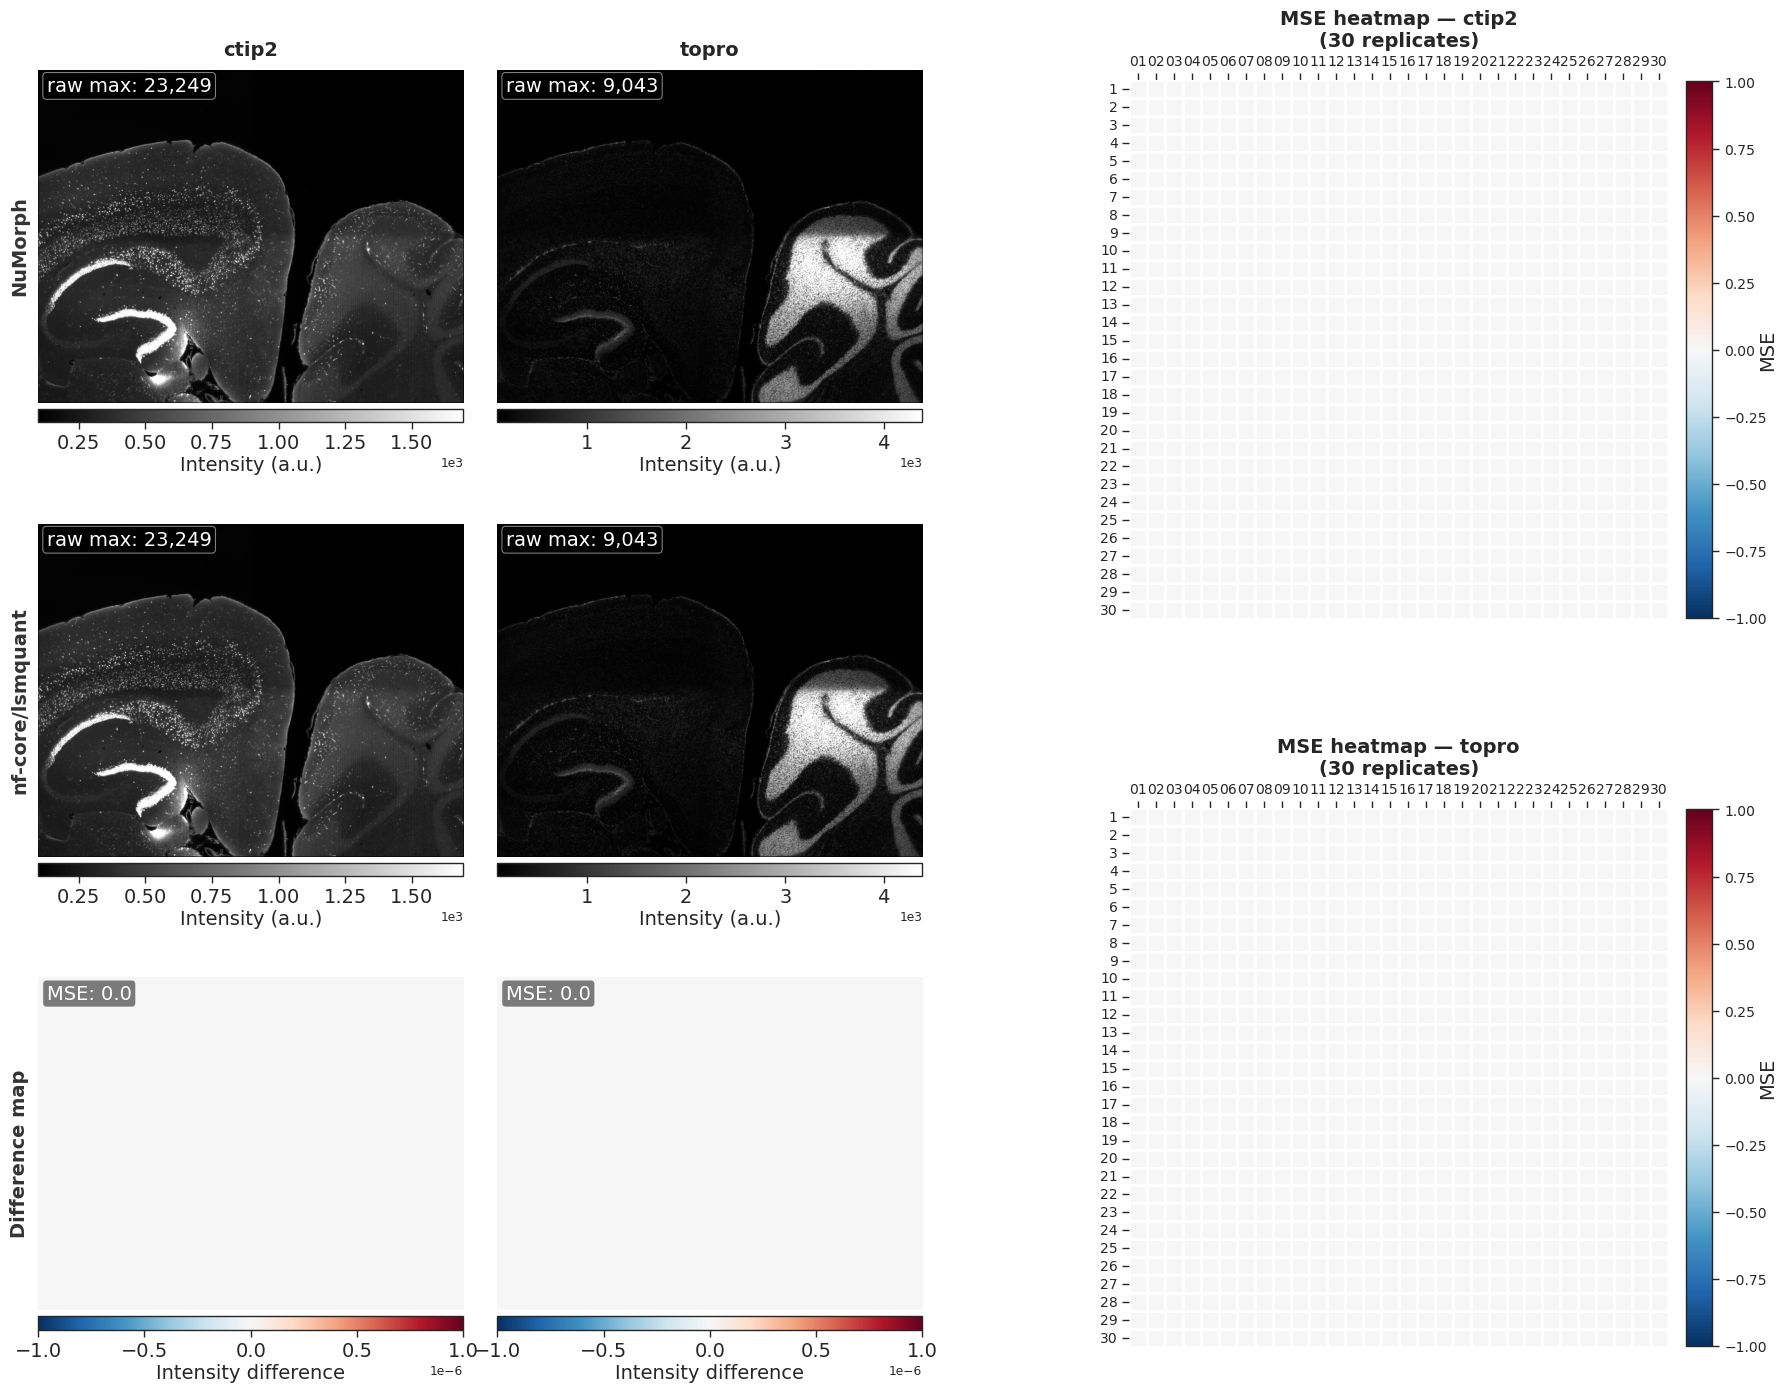

In [ ]:

# --- channel definitions ---------------------------------------------------- #
channels = [
    {
        "name":    "ctip2",
        "img_nm":  rot90_ccw(numorph_img_ctip2_z0009),
        "img_lsm": rot90_ccw(lsmquant_img_ctip2_z0009),
        "diff":    rot90_ccw(diff_ctip2),
        "mse":     mse_ctip2,
        "mse_df":  mse_df_C1,
    },
    {
        "name":    "topro",
        "img_nm":  rot90_ccw(numorph_img_topro_z0009),
        "img_lsm": rot90_ccw(lsmquant_img_topro_z0009),
        "diff":    rot90_ccw(diff_topro),
        "mse":     mse_topro,
        "mse_df":  mse_df_C2,
    },
]

# --- SVG settings ------------------------------------------
new_rc_params = {"text.usetex": False, "svg.fonttype": "none"}
plt.rcParams.update(new_rc_params)
sns.set_context("paper")
sns.set_style("white", {"xtick.bottom": True, "ytick.left": True})
locale.setlocale(locale.LC_ALL, "en_US.UTF-8")
plt.rcParams["axes.formatter.use_locale"] = True
 
# --- shared vmin/vmax per channel ---------------------------------------------------- #
# get the percentile stretch for numorph image 
# apply to both images to visualize potential brightness differences between the two images.

for ch in channels:
    ch["vmin"], ch["vmax"] = percentile_stretch(ch["img_nm"]) 
row_labels = ["NuMorph", "nf-core/lsmquant", "Difference map"]
 
# --- top-level figure: 2 subfigures side by side ---------------------------------------------------- #
# Left subfig  → 3×2 image grid  (width_ratio 2)
# Right subfig → 2 stacked heatmaps (width_ratio 1)

fig = plt.figure(figsize=(19, 14))
fig.patch.set_facecolor("white")
 
sf_left, sf_right = fig.subfigures(
    1, 2,
    width_ratios=[1, 1],
    wspace=0.02,
)
 
# ==============================================================================
# LEFT SUBFIGURE — image grid 
# ==============================================================================
gs_left = gridspec.GridSpec(
    3, 2,
    figure=sf_left,
    hspace=0.04,
    wspace=0.08,
    left=0.04, right=0.98,
    top=0.98, bottom=0.02,
)
 
for col_idx, ch in enumerate(channels):
    for row_idx in range(3):
 
        ax_img = sf_left.add_subplot(gs_left[row_idx, col_idx])
 
        if row_idx == 0:
            img, vmin, vmax = ch["img_nm"], ch["vmin"], ch["vmax"]
            cmap, clabel, norm = "gray", "Intensity (a.u.)", None
            print(f"{ch['name']} numorph - data type is {ch['img_nm'].dtype}")
        elif row_idx == 1:
            img, vmin, vmax = ch["img_lsm"], ch["vmin"], ch["vmax"]
            cmap, clabel, norm = "gray", "Intensity (a.u.)", None
            print(f"{ch['name']} lsmquant - data type is {ch['img_lsm'].dtype}")
        else:
            diff_max = ch["diff"].max()
            diff_min = ch["diff"].min()

            if diff_max < 1e-6:
                diff_max = 1e-6
                diff_min = -1e-6

            img   = ch["diff"]
            vmin, vmax = diff_min, diff_max
            cmap  = "RdBu_r"
            clabel = "Intensity difference"
            #norm  = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
            print(f"{ch['name']} difference map - data type is {ch['diff'].dtype}")
 
        im = ax_img.imshow(
            img, cmap=cmap,
            **({"norm": norm} if norm else {"vmin": vmin, "vmax": vmax})
        )
        ax_img.axis("off")
 
        # annotations
        if row_idx < 2:
            ax_img.text(
                0.02, 0.98, f"raw max: {int(np.max(img)):,}",
                transform=ax_img.transAxes, fontsize=ANNOT_FONTSIZE,
                color="white", va="top",
                bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.5),
            )
        else:
            ax_img.text(
                0.02, 0.98, f"MSE: {ch['mse']}",
                transform=ax_img.transAxes, fontsize=ANNOT_FONTSIZE,
                color="white", va="top",
                bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.5),
            )
 
        # colorbar glued below image
        divider = make_axes_locatable(ax_img)
        cbar_ax = divider.append_axes("bottom", size="4%", pad=0.06)
        cb = sf_left.colorbar(im, cax=cbar_ax, orientation="horizontal")
        cb.set_label(clabel, fontsize=CBAR_FONTSIZE, labelpad=2)
        cb.ax.tick_params(labelsize=ANNOT_FONTSIZE)
        cb.formatter.set_powerlimits((0, 0))
        cb.update_ticks()
 
        # row labels on leftmost column
        if col_idx == 0:
            slot = gs_left[row_idx, 0].get_position(sf_left)
            sf_left.text(
                0.01, slot.y0 + slot.height / 2,
                row_labels[row_idx],
                fontsize=LABEL_FONTSIZE, fontweight="bold",
                ha="left", va="center", rotation=90, color=LABEL_COLOR,
            )
 
        # column titles on top row
        if row_idx == 0:
            ax_img.set_title(ch["name"], fontsize=TITLE_FONTSIZE,
                             fontweight="bold", pad=10)
 
# ==============================================================================
# RIGHT SUBFIGURE — stacked MSE heatmaps
# ==============================================================================
gs_right = gridspec.GridSpec(
    2, 1,
    figure=sf_right,
    hspace=0.30,
    left=0.18, right=0.80,
    top=0.95, bottom=0.03,
)
 
for hm_idx, ch in enumerate(channels):
    ax_hm = sf_right.add_subplot(gs_right[hm_idx, 0])
 
    df   = ch["mse_df"]
    data = df.values.astype(float)
 
    hm_abs_max = np.nanpercentile(np.abs(data), 99.5)
    if hm_abs_max < 1e-9:
        hm_abs_max = 1e-9
 
    im_hm, cbar_hm = heatmap(
        data,
        row_labels=df.index,
        col_labels=df.columns,
        ax=ax_hm,
        cmap="RdBu_r",
        vmin=-hm_abs_max,
        vmax=hm_abs_max,
        cbarlabel="MSE",
        cbar_kw={"fraction": 0.046, "pad": 0.03},
    )
    cbar_hm.ax.tick_params(labelsize=10)
    cbar_hm.ax.yaxis.label.set_fontsize(CBAR_FONTSIZE)
    cbar_hm.ax.yaxis.get_offset_text().set_visible(False)
    cbar_hm.formatter.set_powerlimits((0, 0))
    cbar_hm.update_ticks()
    ax_hm.tick_params(axis="both", labelsize=10)
    ax_hm.set_title(
        f"MSE heatmap — {ch['name']}\n(30 replicates)",
        fontsize=TITLE_FONTSIZE, fontweight="bold", pad=6,
    )

# use this to save the figure as a high-resolution PNG or SVG file
#plt.savefig("./figures/Figure_4_stitch_comparison_test_dataset.png", dpi=350, bbox_inches="tight",
#            facecolor="white")
#plt.savefig("./figures/Figure_4_stitch_comparison_test_dataset.svg", dpi=350, bbox_inches="tight",
#            facecolor="white")

plt.show()


## Comparison of stitched out put for a full mouse. brain dataset 


In [9]:
zslice = "0507"

In [10]:
# output comparison stitched images for the large dataset
# use the zslice parameter to faster change which z i want to see 

#--- lsmquant output stitched 08.07.26 --------------------------------
lsmquant_stitched_path = "/mnt/ssd/numorph_full_datasets/nf-core_lsmquant_out_0807/numorphstitch/L73D766P9/stitched"
# images run2 3 channels z 0507
lsmquant_C1_topro = tifffile.imread(lsmquant_stitched_path + "/L73D766P9_" + zslice + "_C1_topro_stitched.tif")
lsmquant_C2_brn2 = tifffile.imread(lsmquant_stitched_path + "/L73D766P9_" + zslice + "_C2_brn2_stitched.tif")
lsmquant_C3_ctip2 = tifffile.imread(lsmquant_stitched_path + "/L73D766P9_" + zslice + "_C3_ctip2_stitched.tif")


#--- numorph output stitched: 09.06.26 --------------------------------
numorph_stitched_path = "/mnt/ssd/numorph_full_datasets/native_numorph/output_L73D766P9_monitor_090626/stitched"
# numorph images from 3 channels
nm_C1_topro = tifffile.imread(numorph_stitched_path + "/L73D766P9_" + zslice + "_C1_topro_stitched.tif")
nm_C2_brn2 = tifffile.imread(numorph_stitched_path + "/L73D766P9_" + zslice + "_C2_brn2_stitched.tif")
nm_C3_ctip2 = tifffile.imread(numorph_stitched_path + "/L73D766P9_" + zslice + "_C3_ctip2_stitched.tif")



#### calculate mse for lsmquant run 2 and numorph for all topro images

create boxplots of mses for each channel mse is always calculated per z slice 

In [10]:
#mse array for topro

mse_topro_lsmquant_numorph = []
# iterate through the stitched images in the numorph output directory and find the corresponding lsmquant image in the lsmquant output directory
for image in glob.glob(numorph_stitched_path + "/*.tif"):
    if image.endswith("_C1_topro_stitched.tif"):
        # find the corresponding lsmquant image
        lsmquant_image = image.replace(numorph_stitched_path, lsmquant_stitched_path)
        print(image)
        print(lsmquant_image)
        if os.path.exists(lsmquant_image):
            # read both images
            numorph_img = tifffile.imread(image)
            lsmquant_img = tifffile.imread(lsmquant_image)
            # calculate MSE and append to the list
            mse_value = mse(numorph_img.astype(np.float64), lsmquant_img.astype(np.float64))
            mse_topro_lsmquant_numorph.append(mse_value)

/mnt/ssd/numorph_full_datasets/native_numorph/output_L73D766P9_monitor_090626/stitched/L73D766P9_0495_C1_topro_stitched.tif
/mnt/ssd/numorph_full_datasets/nf-core_lsmquant_out_0807/numorphstitch/L73D766P9/stitched/L73D766P9_0495_C1_topro_stitched.tif
/mnt/ssd/numorph_full_datasets/native_numorph/output_L73D766P9_monitor_090626/stitched/L73D766P9_0696_C1_topro_stitched.tif
/mnt/ssd/numorph_full_datasets/nf-core_lsmquant_out_0807/numorphstitch/L73D766P9/stitched/L73D766P9_0696_C1_topro_stitched.tif
/mnt/ssd/numorph_full_datasets/native_numorph/output_L73D766P9_monitor_090626/stitched/L73D766P9_0977_C1_topro_stitched.tif
/mnt/ssd/numorph_full_datasets/nf-core_lsmquant_out_0807/numorphstitch/L73D766P9/stitched/L73D766P9_0977_C1_topro_stitched.tif
/mnt/ssd/numorph_full_datasets/native_numorph/output_L73D766P9_monitor_090626/stitched/L73D766P9_0970_C1_topro_stitched.tif
/mnt/ssd/numorph_full_datasets/nf-core_lsmquant_out_0807/numorphstitch/L73D766P9/stitched/L73D766P9_0970_C1_topro_stitched.

In [14]:
mse_topro_lsmquant_numorph.sort()
mse_topro_lsmquant_numorph[-1]


0.0

In [13]:
#mse array for ctip2
mse_ctip2_lsmquant_numorph = []
# iterate through the stitched images in the numorph output directory and find the corresponding lsmquant image in the lsmquant output directory
for image in glob.glob(numorph_stitched_path + "/*.tif"):
    if image.endswith("_C3_ctip2_stitched.tif"):
        # find the corresponding lsmquant image
        lsmquant_image = image.replace(numorph_stitched_path, lsmquant_stitched_path)
        print(image)
        print(lsmquant_image)
        if os.path.exists(lsmquant_image):
            # read both images
            numorph_img = tifffile.imread(image)
            lsmquant_img = tifffile.imread(lsmquant_image)
            # calculate MSE and append to the list
            mse_value = mse(numorph_img.astype(np.float64), lsmquant_img.astype(np.float64))
            mse_ctip2_lsmquant_numorph.append(mse_value)

/mnt/ssd/numorph_full_datasets/native_numorph/output_L73D766P9_monitor_090626/stitched/L73D766P9_0654_C3_ctip2_stitched.tif
/mnt/ssd/numorph_full_datasets/nf-core_lsmquant_out_0807/numorphstitch/L73D766P9/stitched/L73D766P9_0654_C3_ctip2_stitched.tif
/mnt/ssd/numorph_full_datasets/native_numorph/output_L73D766P9_monitor_090626/stitched/L73D766P9_0587_C3_ctip2_stitched.tif
/mnt/ssd/numorph_full_datasets/nf-core_lsmquant_out_0807/numorphstitch/L73D766P9/stitched/L73D766P9_0587_C3_ctip2_stitched.tif
/mnt/ssd/numorph_full_datasets/native_numorph/output_L73D766P9_monitor_090626/stitched/L73D766P9_0820_C3_ctip2_stitched.tif
/mnt/ssd/numorph_full_datasets/nf-core_lsmquant_out_0807/numorphstitch/L73D766P9/stitched/L73D766P9_0820_C3_ctip2_stitched.tif
/mnt/ssd/numorph_full_datasets/native_numorph/output_L73D766P9_monitor_090626/stitched/L73D766P9_0038_C3_ctip2_stitched.tif
/mnt/ssd/numorph_full_datasets/nf-core_lsmquant_out_0807/numorphstitch/L73D766P9/stitched/L73D766P9_0038_C3_ctip2_stitched.

In [15]:
mse_ctip2_lsmquant_numorph.sort()
mse_ctip2_lsmquant_numorph[-1]

0.0

In [16]:
# mse array for brn2
mse_brn2_lsmquant_numorph = []
# iterate through the stitched images in the numorph output directory and find the corresponding lsmquant image in the lsmquant output directory
for image in glob.glob(numorph_stitched_path + "/*.tif"):
    if image.endswith("_C2_brn2_stitched.tif"):
        # find the corresponding lsmquant image
        lsmquant_image = image.replace(numorph_stitched_path, lsmquant_stitched_path)
        print(image)
        print(lsmquant_image)
        if os.path.exists(lsmquant_image):
            # read both images
            numorph_img = tifffile.imread(image)
            lsmquant_img = tifffile.imread(lsmquant_image)
            # calculate MSE and append to the list
            mse_value = mse(numorph_img.astype(np.float64), lsmquant_img.astype(np.float64))
            mse_brn2_lsmquant_numorph.append(mse_value)

/mnt/ssd/numorph_full_datasets/native_numorph/output_L73D766P9_monitor_090626/stitched/L73D766P9_0325_C2_brn2_stitched.tif
/mnt/ssd/numorph_full_datasets/nf-core_lsmquant_out_0807/numorphstitch/L73D766P9/stitched/L73D766P9_0325_C2_brn2_stitched.tif
/mnt/ssd/numorph_full_datasets/native_numorph/output_L73D766P9_monitor_090626/stitched/L73D766P9_0378_C2_brn2_stitched.tif
/mnt/ssd/numorph_full_datasets/nf-core_lsmquant_out_0807/numorphstitch/L73D766P9/stitched/L73D766P9_0378_C2_brn2_stitched.tif
/mnt/ssd/numorph_full_datasets/native_numorph/output_L73D766P9_monitor_090626/stitched/L73D766P9_0116_C2_brn2_stitched.tif
/mnt/ssd/numorph_full_datasets/nf-core_lsmquant_out_0807/numorphstitch/L73D766P9/stitched/L73D766P9_0116_C2_brn2_stitched.tif
/mnt/ssd/numorph_full_datasets/native_numorph/output_L73D766P9_monitor_090626/stitched/L73D766P9_0382_C2_brn2_stitched.tif
/mnt/ssd/numorph_full_datasets/nf-core_lsmquant_out_0807/numorphstitch/L73D766P9/stitched/L73D766P9_0382_C2_brn2_stitched.tif
/mnt

In [17]:
mse_brn2_lsmquant_numorph.sort()
mse_brn2_lsmquant_numorph[-1]

0.0

In [18]:
# save arrays to csv
np.savetxt("./results/mse_topro_lsmquant_numorph.csv", mse_topro_lsmquant_numorph, delimiter=",")
np.savetxt("./results/mse_ctip2_lsmquant_numorph.csv", mse_ctip2_lsmquant_numorph, delimiter=",")
np.savetxt("./results/mse_brn2_lsmquant_numorph.csv", mse_brn2_lsmquant_numorph, delimiter=",")

#### Read mse per channel per z-plane from file

In [5]:
mse_brn2_lsmquant_numorph = np.loadtxt("./results/mse_brn2_lsmquant_numorph.csv", delimiter=",")
mse_topro_lsmquant_numorph = np.loadtxt("./results/mse_topro_lsmquant_numorph.csv", delimiter=",")
mse_ctip2_lsmquant_numorph = np.loadtxt("./results/mse_ctip2_lsmquant_numorph.csv", delimiter=",")

In [6]:
mse_dict = {
    "topro": mse_topro_lsmquant_numorph,
    "ctip2": mse_ctip2_lsmquant_numorph,
    "brn2": mse_brn2_lsmquant_numorph
}

#### Figure S1

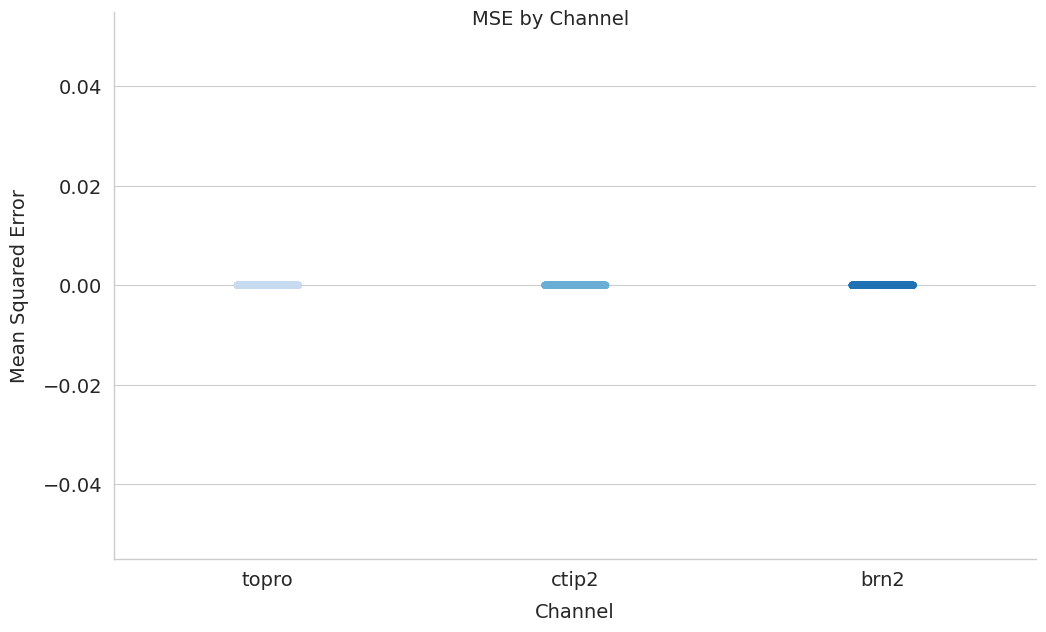

In [7]:
# plot the mse values for each channel as a bar plot
# --- SVG settings ------------------------------------------
new_rc_params = {"text.usetex": False, "svg.fonttype": "none"}
plt.rcParams.update(new_rc_params)
sns.set_context("paper")
sns.set_style("white", {"xtick.bottom": True, "ytick.left": True})
locale.setlocale(locale.LC_ALL, "en_US.UTF-8")
plt.rcParams["axes.formatter.use_locale"] = True

g = sns.set_style("whitegrid")
g = sns.catplot(data=mse_dict, palette="Blues", height=6, aspect=10/6)
g.set_xlabels("Channel", fontsize=14, labelpad=10)
g.tick_params(axis='x', labelsize=14)
g.set_ylabels("Mean Squared Error", fontsize=14, labelpad=10)
g.tick_params(axis='y', labelsize=14)
g.fig.suptitle("MSE by Channel", fontsize=14)
plt.savefig("./figures/Figure_S1_mse_by_channel.png", dpi=350, bbox_inches="tight", facecolor="white")
plt.savefig("./figures/Figure_S1_mse_by_channel.svg", dpi=350, bbox_inches="tight", facecolor="white")
plt.show()

### Figure 5: Stitched output comparison large dataset 

In [14]:
# difference images lsmquant  and numorph 
diff_lsmquant_nm_topro = lsmquant_C1_topro.astype(np.int32) - nm_C1_topro.astype(np.int32)
diff_lsmquant_nm_brn2 = lsmquant_C2_brn2.astype(np.int32) - nm_C2_brn2.astype(np.int32)
diff_lsmquant_nm_ctip2 = lsmquant_C3_ctip2.astype(np.int32) - nm_C3_ctip2.astype(np.int32) 

print("Topro - max difference:", diff_lsmquant_nm_topro.max())
print("Ctip2 - max difference:", diff_lsmquant_nm_ctip2.max())
print("Brn2 - max difference:", diff_lsmquant_nm_brn2.max())

# mse images lsmquant 2 and numorph
mse_lsmquant_nm_topro = mse(lsmquant_C1_topro.astype(np.float64), nm_C1_topro.astype(np.float64))
mse_lsmquant_nm_brn2 = mse(lsmquant_C2_brn2.astype(np.float64), nm_C2_brn2.astype(np.float64))
mse_lsmquant_nm_ctip2 = mse(lsmquant_C3_ctip2.astype(np.float64), nm_C3_ctip2.astype(np.float64))

Topro - max difference: 0
Ctip2 - max difference: 0
Brn2 - max difference: 0


In [30]:

channels = [
    {
        "name":    "topro",
        "im1":     lsmquant_C1_topro,
        "im2":     nm_C1_topro,
        "diff":    diff_lsmquant_nm_topro,
        "mse":     mse_lsmquant_nm_topro
    },
    {
        "name":    "ctip2",
        "im1":     lsmquant_C3_ctip2,
        "im2":     nm_C3_ctip2,
        "diff":    diff_lsmquant_nm_ctip2,
        "mse":     mse_lsmquant_nm_ctip2
    },
    {
        "name":    "brn2",
        "im1":     lsmquant_C2_brn2,
        "im2":     nm_C2_brn2,
        "diff":    diff_lsmquant_nm_brn2,
        "mse":     mse_lsmquant_nm_brn2
    },
]

col_titles = ["nf-core/lsmquant", "NuMorph", "Difference nf-core/lsmquant - NuMorph"]

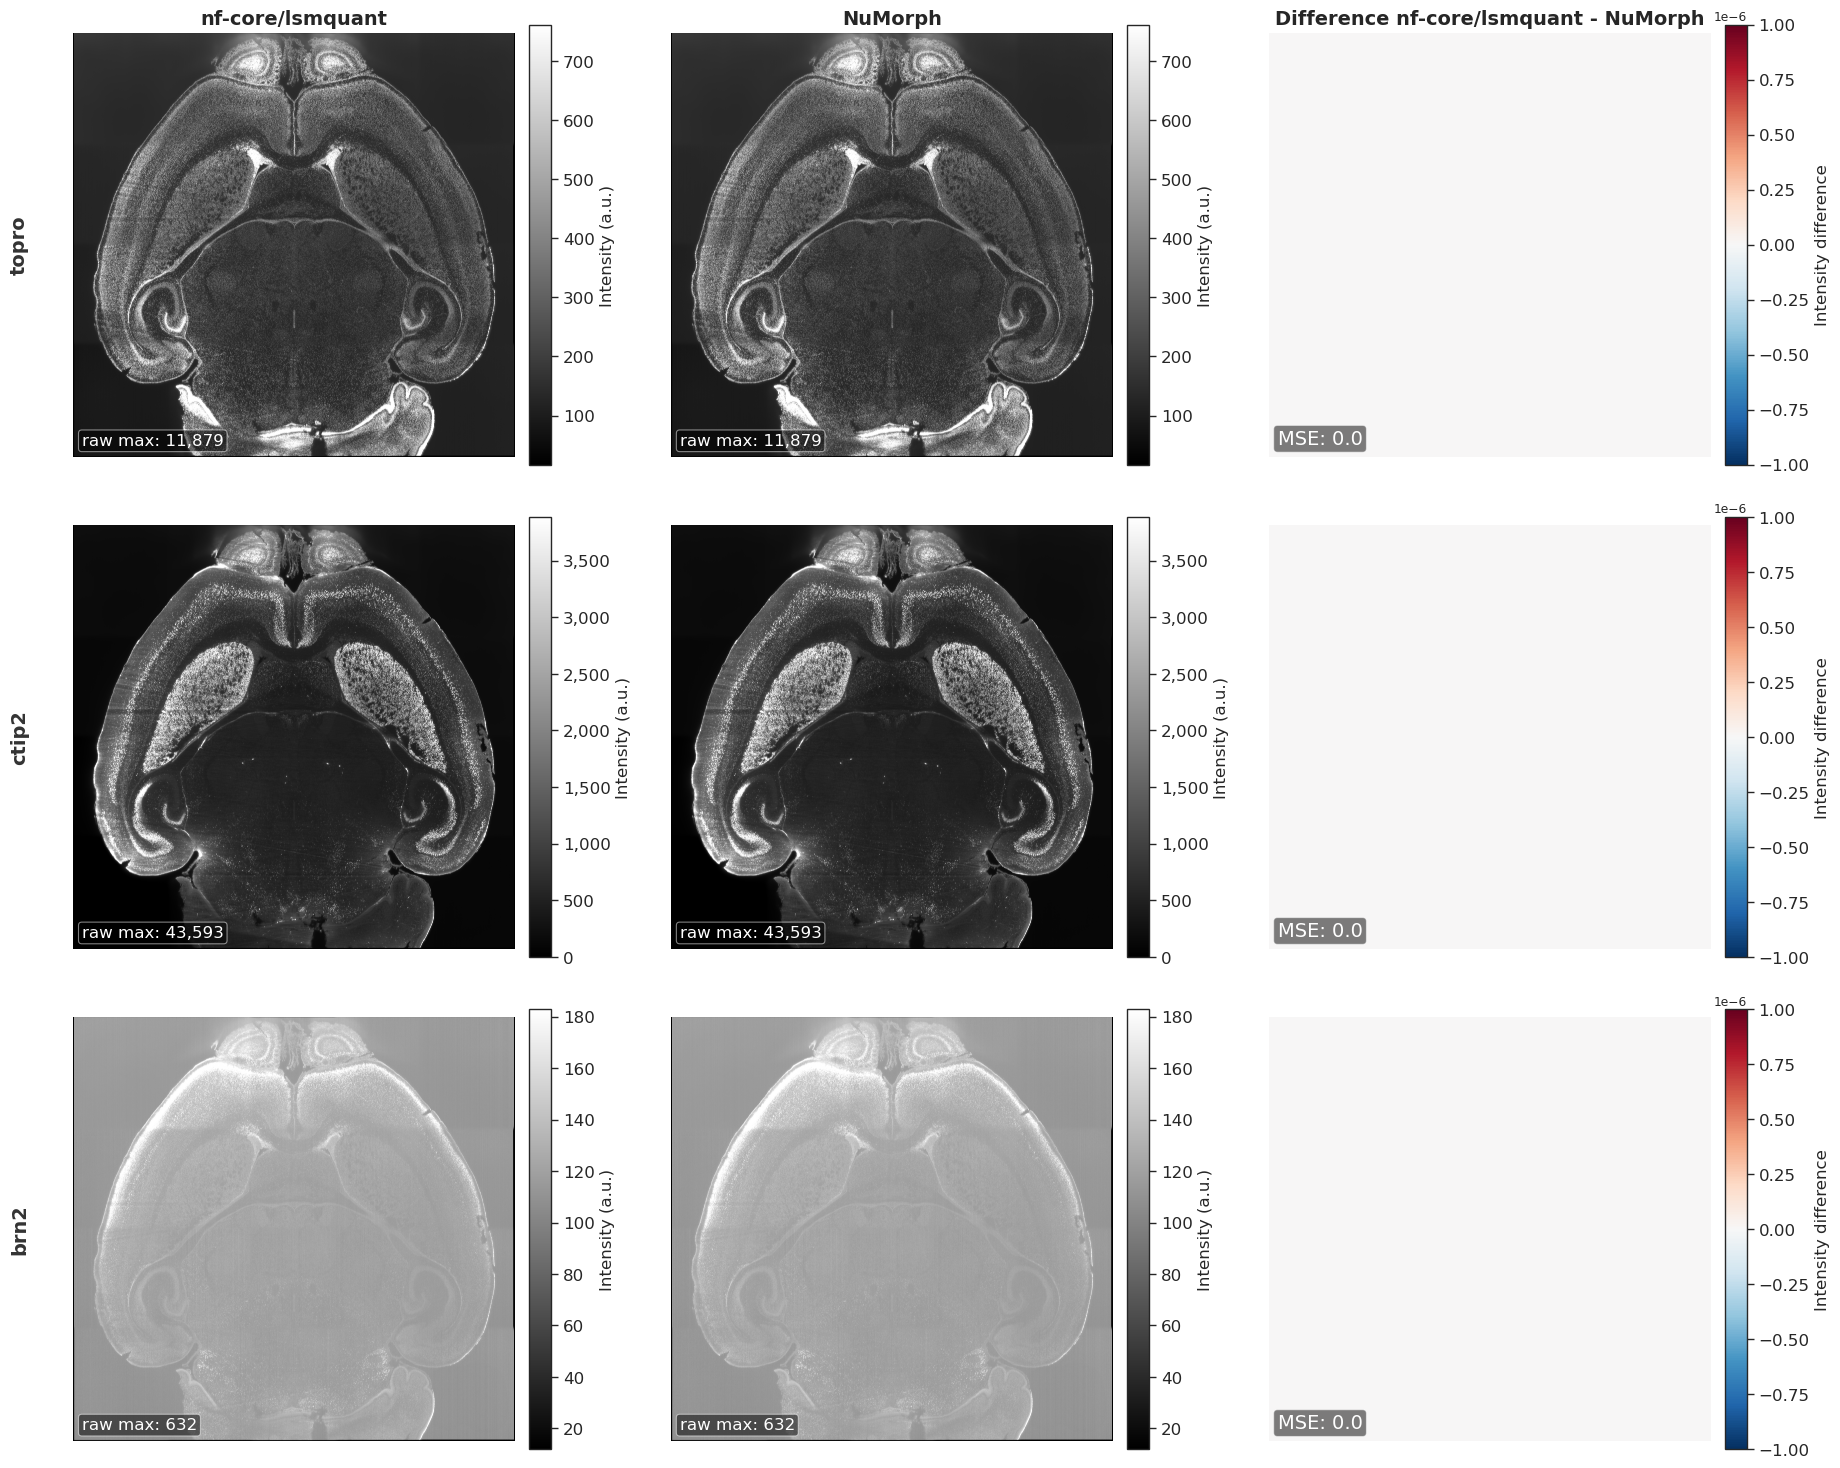

In [31]:

# --- SVG settings ------------------------------------------
new_rc_params = {"text.usetex": False, "svg.fonttype": "none"}
plt.rcParams.update(new_rc_params)
sns.set_context("paper")
sns.set_style("white", {"xtick.bottom": True, "ytick.left": True})
locale.setlocale(locale.LC_ALL, "en_US.UTF-8")
plt.rcParams["axes.formatter.use_locale"] = True

# --- figure layout ------------------------------------------
fig = plt.figure(figsize=(18, 16))
fig.patch.set_facecolor("white")
 
# Use GridSpec for tighter control over spacing
gs = gridspec.GridSpec(
    3, 3,
    figure=fig,
    hspace=0.08,   # tight vertical gap between rows
    wspace=0.25,   # room for colorbars
    left=0.04, right=0.97,
    top=0.94, bottom=0.04,
)
 
# --- plot ------------------------------------------
for row, ch in enumerate(channels):
    img_1  = ch["im1"]
    img_2 = ch["im2"]
    diff    = img_1.astype(np.int32) - img_2.astype(np.int32)
 
    # Per-channel percentile stretch (same limits for both pipelines so they
    # are directly comparable within a row)
    vmin, vmax = percentile_stretch(img_1, low=1, high=99)
 
    # Difference colormap: diverging, symmetric around 0
    # Use the actual data range (capped at ±0.1 as in original) so small
    # differences don't get artificially amplified
    diff_max = diff.max()
    diff_min = diff.min()
    if diff_max < 1e-6:
        #Images are effectively identical — use a tiny symmetric range
        #and the diff map will appear uniformly white (centered)
                diff_max = 1e-6
                diff_min = -1e-6
                diff_norm = TwoSlopeNorm(vmin=diff_min, vcenter=0, vmax=diff_max)
    else:
         diff_norm = TwoSlopeNorm(vmin=diff_min, vcenter=0, vmax=diff_max)
    
    for col in range(3):
        ax = fig.add_subplot(gs[row, col])
 
        # ── column 0: NuMorph ──
        if col == 0:
            im = ax.imshow(img_1, cmap="gray", vmin=vmin, vmax=vmax)
            cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
            cb.set_label("Intensity (a.u.)", fontsize=12)
            cb.ax.tick_params(labelsize=12)
            # Annotate the raw max so the reader sees the true scale
            raw_max = int(np.max(img_1))
            ax.text(0.02, 0.02, f"raw max: {raw_max:,}",
                    transform=ax.transAxes, fontsize=12,
                    color="white", va="bottom",
                    bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.5))
 
        # ── column 1: nf-core/lsmquant ──
        elif col == 1:
            im = ax.imshow(img_2, cmap="gray", vmin=vmin, vmax=vmax)
            cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
            cb.set_label("Intensity (a.u.)", fontsize=12)
            cb.ax.tick_params(labelsize=12)
            # Annotate the raw max so the reader sees the true scale
            raw_max = int(np.max(img_2))
            ax.text(0.02, 0.02, f"raw max: {raw_max:,}",
                    transform=ax.transAxes, fontsize=12,
                    color="white", va="bottom",
                    bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.5))
 
        # ── column 2: difference map ──
        else:
            im = ax.imshow(diff, cmap="RdBu_r", norm=diff_norm)
            cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
            cb.set_label("Intensity difference", fontsize=12)
            cb.ax.tick_params(labelsize=12)
            #Annotate with mse value
            
            pct = 100 * np.percentile(np.abs(diff), 99.5) / (vmax - vmin) if (vmax - vmin) > 0 else 0
            ax.text(0.02, 0.02, f"MSE: {ch['mse']}",
                    transform=ax.transAxes, fontsize=ANNOT_FONTSIZE,
                    color="white", va="bottom",
                    bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.5))

        ax.axis("off")
 
        # Column titles on first row only
        if row == 0:
            ax.set_title(col_titles[col], fontsize=TITLE_FONTSIZE, fontweight="bold", pad=6)
 
        # Channel label on left side of col 0
        if col == 0:
            ax.set_ylabel(ch["name"], fontsize=LABEL_FONTSIZE, fontweight="bold",
                          rotation=90, labelpad=6)
            ax.yaxis.set_label_position("left")
            ax.axis("off")   # keep axis off but ylabel still renders via text
            # Use fig.text for reliable positioning
            fig.text(
                0.005,
                # vertically centre within this row's GridSpec slot
                gs[row, 0].get_position(fig).y0 +
                gs[row, 0].get_position(fig).height / 2,
                ch["name"],
                fontsize=LABEL_FONTSIZE, fontweight="bold",
                ha="left", va="center", rotation=90,
                color="#333333",
            )

plt.savefig("./figures/Figure_5_stitch_comparison_large_dataset.png", dpi=350, bbox_inches="tight",
            facecolor="white")
plt.savefig("./figures/Figure_5_stitch_comparison_large_dataset.svg", dpi=350, bbox_inches="tight",
            facecolor="white")
plt.show()
